# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

[1.00813719e+02 8.09056044e+01 2.10048206e-02]


C:\Users\tomas\AppData\Local\Temp\ipykernel_25164\3796845697.py:7: RuntimeWarning: overflow encountered in exp
  return inf - A * np.exp(-k * x)


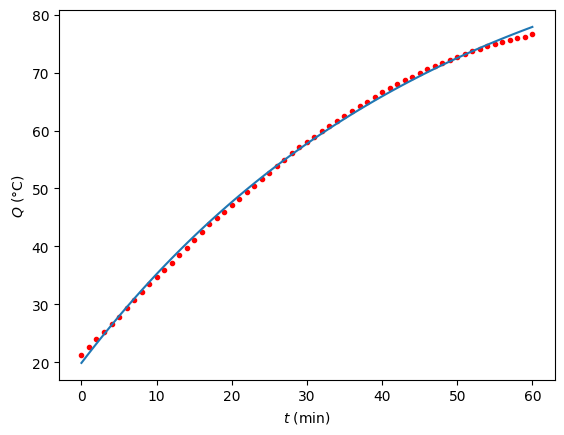

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Opgave 1
def fit(x, inf, A, k):
    return inf - A * np.exp(-k * x)


t,q = np.loadtxt("tempmetingen.csv", delimiter=";", dtype=str ,unpack=True)

# Wegens een fout in de file was de eerste waarde van t incorrect en moest dit gecorrigeerd worden
# Er was een BOM (Byte Order Mark) aanwezig, die door browsers geïnterpreteerd wordt, maar niet door python
t[0] = 0
t = [float(i) for i in t]
q = [float(p) for p in q]

popt, pcov = curve_fit(fit, t, q)
print(popt)
x_test = np.linspace(0, 60, 81)
y = fit(x_test, *popt)

plt.figure()
plt.plot(t,q, 'r.')
plt.plot(x_test, y)
plt.xlabel("$t$ (min)")
plt.ylabel("$Q$ (°C)")
plt.show()

In [ ]:
# Opgave 2

c  = 4180 # verdampingswarmte water 
m_water = 1292.9 - 820.8
DT = q[-1] - q[0]
m_verd = 1292.9 - 1274.9 # Hoeveelheid verdampt water
L = 2.26 * 10**6 # verdampingswarmte

Q_opw = m_water * c * DT # Energie voor d opwarming
Q_verd = m_verd * L # Energie voor de verdamping

# Warmteverlies wordt hier verwaarloosd
Q = Q_opw + Q_verd
# Hier is een schatting gemaakt van de hoeveelheid toegevoegde energie
E = 4.16 * 10**4 * 3600 # E = P * t

# Ik raad aan om de volgende keer de energie die het warmte element toe voegt te bepalen. Zo kan je precieser werken en kijken of het correct is

150005141.2 149760000.0 245141.19999998808
